# NEOMOD3 vs S3M — NEO orbital elements, and why we are switching the clone source

**Question:** should the VDP NEO clone source be **S3M** (the synthetic catalog we have been using) or
**NEOMOD3** (Nesvorny et al. 2024, a *debiased* NEO model fit to real survey detections)?

**Short answer from this notebook:** NEOMOD3. It covers the faint population S3M simply does not have,
it is smooth where S3M shows generation artifacts, and it is debiased rather than synthetic. The cost is
that NEOMOD3 and S3M genuinely *disagree* about the NEO orbital shape (q, e, i) — that disagreement is
real, survives an H-matched cut, and is a deliberate consequence of the switch, not a bug.

Everything here is **read-only**: no production map, parquet, or figure was modified.

- Red = **S3M** source NEO (real catalog objects, 268,511)
- Blue = **NEOMOD3** (debiased model, sampled directly from the datacube — **no GMM fit**, 485,084)


## Background — what changed and why

The current production NEO cloner (`_clone_neo_gmm` in `velocity_density_pipeline_gmm.py`) does this:

1. take the **visible S3M NEOs** in the sky patch,
2. *augment* them with NEOMOD3 samples,
3. fit a **Gaussian Mixture** to the combined set,
4. sample clones from that GMM,
5. attach `H` drawn from the **S3M empirical** distribution (never NEOMOD3's own H).

So even where NEOMOD3 was already involved, its distribution was **re-smoothed through a GMM**, and its
H information was **discarded**. That is the "GMM smooths the distribution" problem noted in
`docs/cloning_gmm_neo.md` (the q spike near 1.1–1.3 gets washed out).

**The new plan:** drop cloning for MBA / TNO / Trojan entirely, and for NEO sample **directly from
NEOMOD3** — no GMM, no S3M anchor.

This notebook is the evidence check before writing that module.


## Files, data, and provenance

In [1]:
import json

from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, display

W   = Path("/mmfs1/gscratch/dirac/ds2004/sorcha")
OUT = W/"outputs/neomod3_vs_s3m_comparison"
pd.set_option("display.width", 200)

files = pd.DataFrame([
 ("NEOMOD3 datacube (62 MB)",        "neomod/NEOMOD3/input_neomod3.dat",             "the binned model itself"),
 ("NEOMOD3 sampler",                 "neomod/src/neomod3_sampler.py",                "loads the 4D table, samples orbits"),
 ("NEOMOD3 reader (older)",          "neomod/src/NEOMOD3.py",                        "alternate parser -> array4D"),
 ("comparison script (base)",        "neomod/pipeline/compare_s3m_vs_neomod3.py",    "loads S3M + samples NEOMOD3, 1D plot"),
 ("comparison script (extended)",    "neomod/pipeline/compare_s3m_vs_neomod3_extended.py", "H<25 cut, 2D, faint tail"),
 ("current production cloner",       "neomod/src/velocity_density_pipeline_gmm.py",  "_clone_neo_gmm (GMM, to be replaced)"),
 ("S3M NEO source (saved)",          "outputs/neomod3_vs_s3m_comparison/s3m_source_neo.parquet",  "268,511 real S3M NEOs"),
 ("NEOMOD3 samples (saved)",         "outputs/neomod3_vs_s3m_comparison/neomod3_samples.parquet", "485,084 sampled orbits"),
 ("stats (full + H<25)",             "outputs/neomod3_vs_s3m_comparison/s3m_vs_neomod3_stats_full_and_Hcut.csv", "KS + summary"),
], columns=["what","path","note"])
display(files)

print("Upstream reference (SWRI, David Nesvorny):")
print("  https://www2.boulder.swri.edu/~davidn/NEOMOD_Simulator/")
print("    input_neomod3.dat    <- the datacube (WE ALREADY HAVE THIS, locally)")
print("    neomod3_simulator.f  <- reference Fortran sampler (validation reference only)")
print("    neomod3.par          <- its parameter file (seed, N, diameter range)")
print("  paper: NEOMOD3, arXiv:2404.18805")


Upstream reference (SWRI, David Nesvorny):
  https://www2.boulder.swri.edu/~davidn/NEOMOD_Simulator/
    input_neomod3.dat    <- the datacube (WE ALREADY HAVE THIS, locally)
    neomod3_simulator.f  <- reference Fortran sampler (validation reference only)
    neomod3.par          <- its parameter file (seed, N, diameter range)
  paper: NEOMOD3, arXiv:2404.18805


,what,path,note
0,NEOMOD3 datacube (62 MB),neomod/NEOMOD3/input_neomod3.dat,the binned model itself
1,NEOMOD3 sampler,neomod/src/neomod3_sampler.py,"loads the 4D table, samples orbits"
2,NEOMOD3 reader (older),neomod/src/NEOMOD3.py,alternate parser -> array4D
3,comparison script (base),neomod/pipeline/compare_s3m_vs_neomod3.py,"loads S3M + samples NEOMOD3, 1D plot"
4,comparison script (extended),neomod/pipeline/compare_s3m_vs_neomod3_extended.py,"H<25 cut, 2D, faint tail"
5,current production cloner,neomod/src/velocity_density_pipeline_gmm.py,"_clone_neo_gmm (GMM, to be replaced)"
6,S3M NEO source (saved),outputs/neomod3_vs_s3m_comparison/s3m_source_neo.parquet,"268,511 real S3M NEOs"
7,NEOMOD3 samples (saved),outputs/neomod3_vs_s3m_comparison/neomod3_samples.parquet,"485,084 sampled orbits"
8,stats (full + H<25),outputs/neomod3_vs_s3m_comparison/s3m_vs_neomod3_stats_full_and_Hcut.csv,KS + summary


## The NEOMOD3 datacube — what it actually is

`input_neomod3.dat` is **not** a catalog of objects. It is a **binned 4-D probability table**: for each
`(H, a, e, i)` cell it stores a model weight, plus the fractional contribution of 12 source regions
(`nu6`, `3:1`, `5:2`, `7:3`, `8:3`, `9:4`, `11:5`, `2:1`, `inner`, `Hungaria`, `Phocaea`, `JFC`).

To get orbital elements you **sample** it: pick a cell with probability ∝ its weight, then draw a
position inside that cell. That is what `neomod3_sampler.sample_neomod3_orbits()` does; angles
(`node`, `argperi`, `M`) are uniform (the debiased model has no preferred orientation) and `t_p` is
reconstructed from `M` at the map epoch.


In [2]:

grid = pd.DataFrame([
 ("H", 52, 15.0, 28.0, 0.25, "mag  — NEOMOD is calibrated 15<H<28; outside that is extrapolation"),
 ("a", 42, 0.0,  4.2,  0.10, "AU"),
 ("e", 25, 0.0,  1.0,  0.04, ""),
 ("i", 22, 0.0,  88.0, 4.00, "deg"),
], columns=["axis","n_bins","min","max","width","note"])
display(grid)
print(f"total cells = 52*42*25*22 = {52*42*25*22:,}")
print(f"populated rows in the file  = 566,835  ({100*566835/(52*42*25*22):.0f}% occupancy)")
print("\nsource populations (12): nu6, 3:1, 5:2, 7:3, 8:3, 9:4, 11:5, 2:1, inner, Hungaria, Phocaea, JFC")
print("\nNOTE on sampling fidelity:")
print("  reference neomod3_simulator.f : draws (a,e,i) continuously + TRILINEAR interpolation + rejection")
print("  our neomod3_sampler.py        : picks a cell by weight, then dithers UNIFORMLY inside it")
print("  -> both are valid samples of the same binned model; ours is piecewise-constant (histogram-like),")
print("     theirs is piecewise-linear (smoother). Downstream the clones go through a kNN density")
print("     estimator anyway, so this is a fidelity nuance, not a correctness bug.")


total cells = 52*42*25*22 = 1,201,200
populated rows in the file  = 566,835  (47% occupancy)

source populations (12): nu6, 3:1, 5:2, 7:3, 8:3, 9:4, 11:5, 2:1, inner, Hungaria, Phocaea, JFC

NOTE on sampling fidelity:
  reference neomod3_simulator.f : draws (a,e,i) continuously + TRILINEAR interpolation + rejection
  our neomod3_sampler.py        : picks a cell by weight, then dithers UNIFORMLY inside it
  -> both are valid samples of the same binned model; ours is piecewise-constant (histogram-like),
     theirs is piecewise-linear (smoother). Downstream the clones go through a kNN density
     estimator anyway, so this is a fidelity nuance, not a correctness bug.


,axis,n_bins,min,max,width,note
0,H,52,15.0,28.0,0.25,mag — NEOMOD is calibrated 15<H<28; outside that is extrapolation
1,a,42,0.0,4.2,0.10,AU
2,e,25,0.0,1.0,0.04,
3,i,22,0.0,88.0,4.00,deg


## 1 · Full-sample comparison (all H)

The original sanity-check plot, with NEOMOD3 (direct sample, no GMM) in place of the GMM clones.

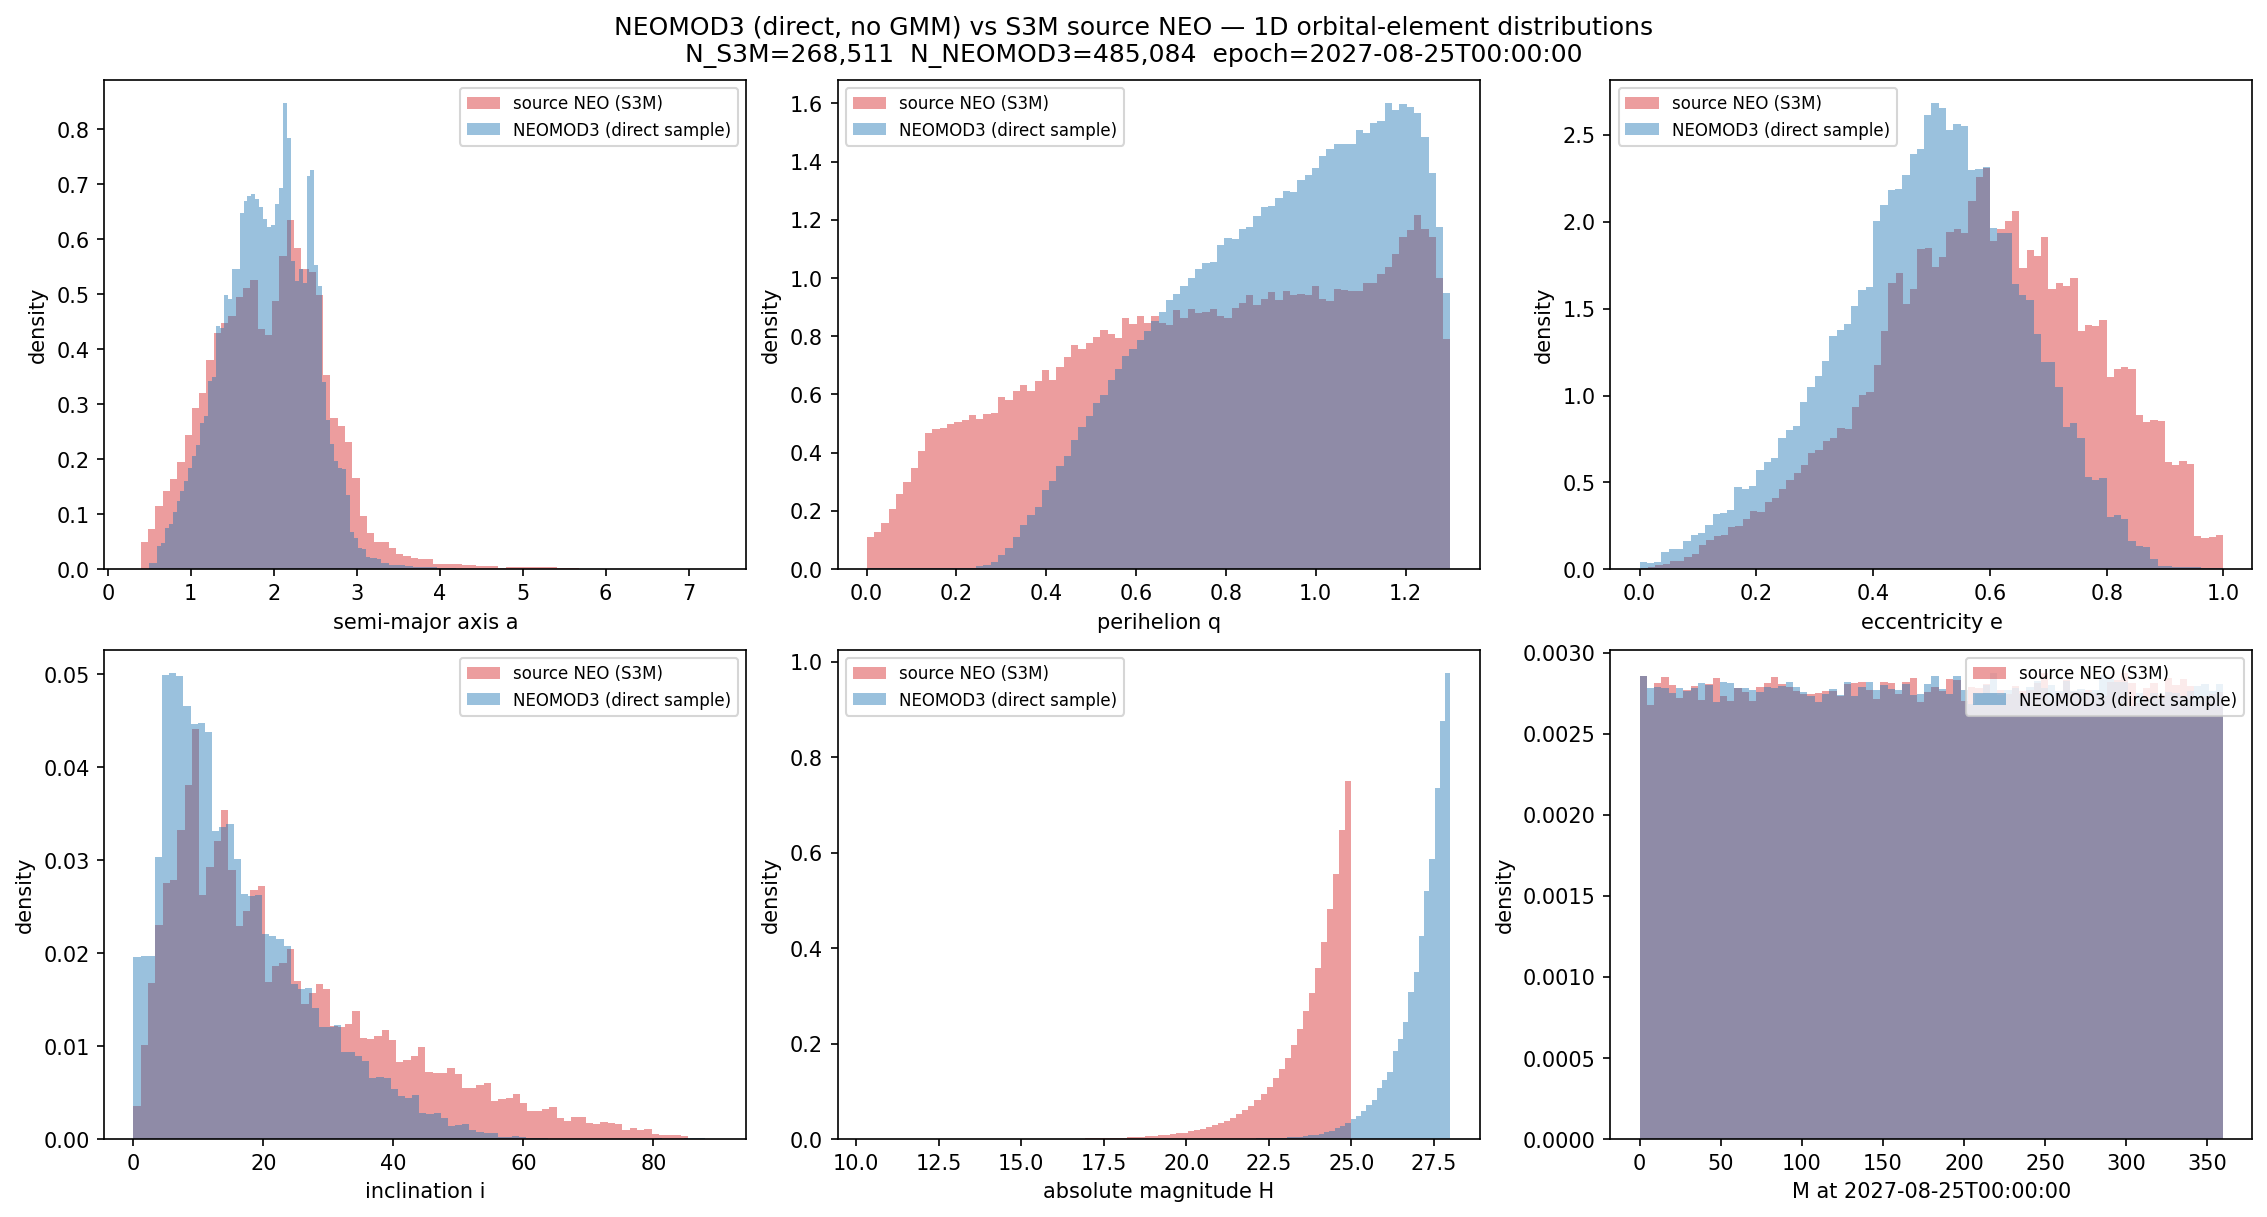

In [3]:
display(Image(filename=str(OUT/"s3m_vs_neomod3_1D.png")))

In [4]:

stats = pd.read_csv(OUT/"s3m_vs_neomod3_stats_full_and_Hcut.csv")
full = stats[stats["sample"]=="full"]
display(full[["column","label","n_s3m","n_neomod3","s3m_median","neomod3_median","s3m_std","neomod3_std","ks_stat"]])


,column,label,n_s3m,n_neomod3,s3m_median,neomod3_median,s3m_std,neomod3_std,ks_stat
0,a,semi-major axis a [AU],268511,485084,1.976464,1.941953,0.705066,0.525427,0.073419
1,q,perihelion q [AU],268511,485084,0.790870,0.952843,0.340928,0.243052,0.213015
2,e,eccentricity e,268511,485084,0.592353,0.503517,0.187509,0.160640,0.222699
3,i,inclination i [deg],268511,485084,18.885782,13.286515,17.126894,11.312799,0.176608
4,H,absolute magnitude H,268511,485084,24.140000,27.372910,1.240538,0.883432,0.969389
5,M_obs_deg,M at 2027-08-25T00:00:00,268511,485084,180.148136,179.997388,103.908572,103.920759,0.001758


**Reading it:**

| element | KS | what it means |
|---|---|---|
| `M` (mean anomaly) | **0.002** (p=0.66) | identical — the **sampler mechanics are correct** (this is the control) |
| `a` | 0.073 | close; S3M has a slightly longer tail beyond 4 AU |
| `q`, `e`, `i` | 0.21 / 0.22 / 0.18 | **real shape disagreement** between the two models |
| `H` | **0.969** | S3M stops dead at H=25; NEOMOD3 continues to 28 |

The `H` panel is the headline: **S3M is truncated at H=25 by construction.** That is exactly the regime
where the survey is most incomplete and where our own ±5 velocity-grid investigation found the 28
stranded high-velocity NEOs (all faint, mag 24–25, sitting right at S3M's edge).


## 2 · Is the q/e/i difference just the H-range mismatch? — **No.**

S3M covers H<25 only, NEOMOD3 mostly H>25, so the full-sample KS mixes two different things. Cutting
**both** samples at H<25 isolates the pure orbital-shape difference.

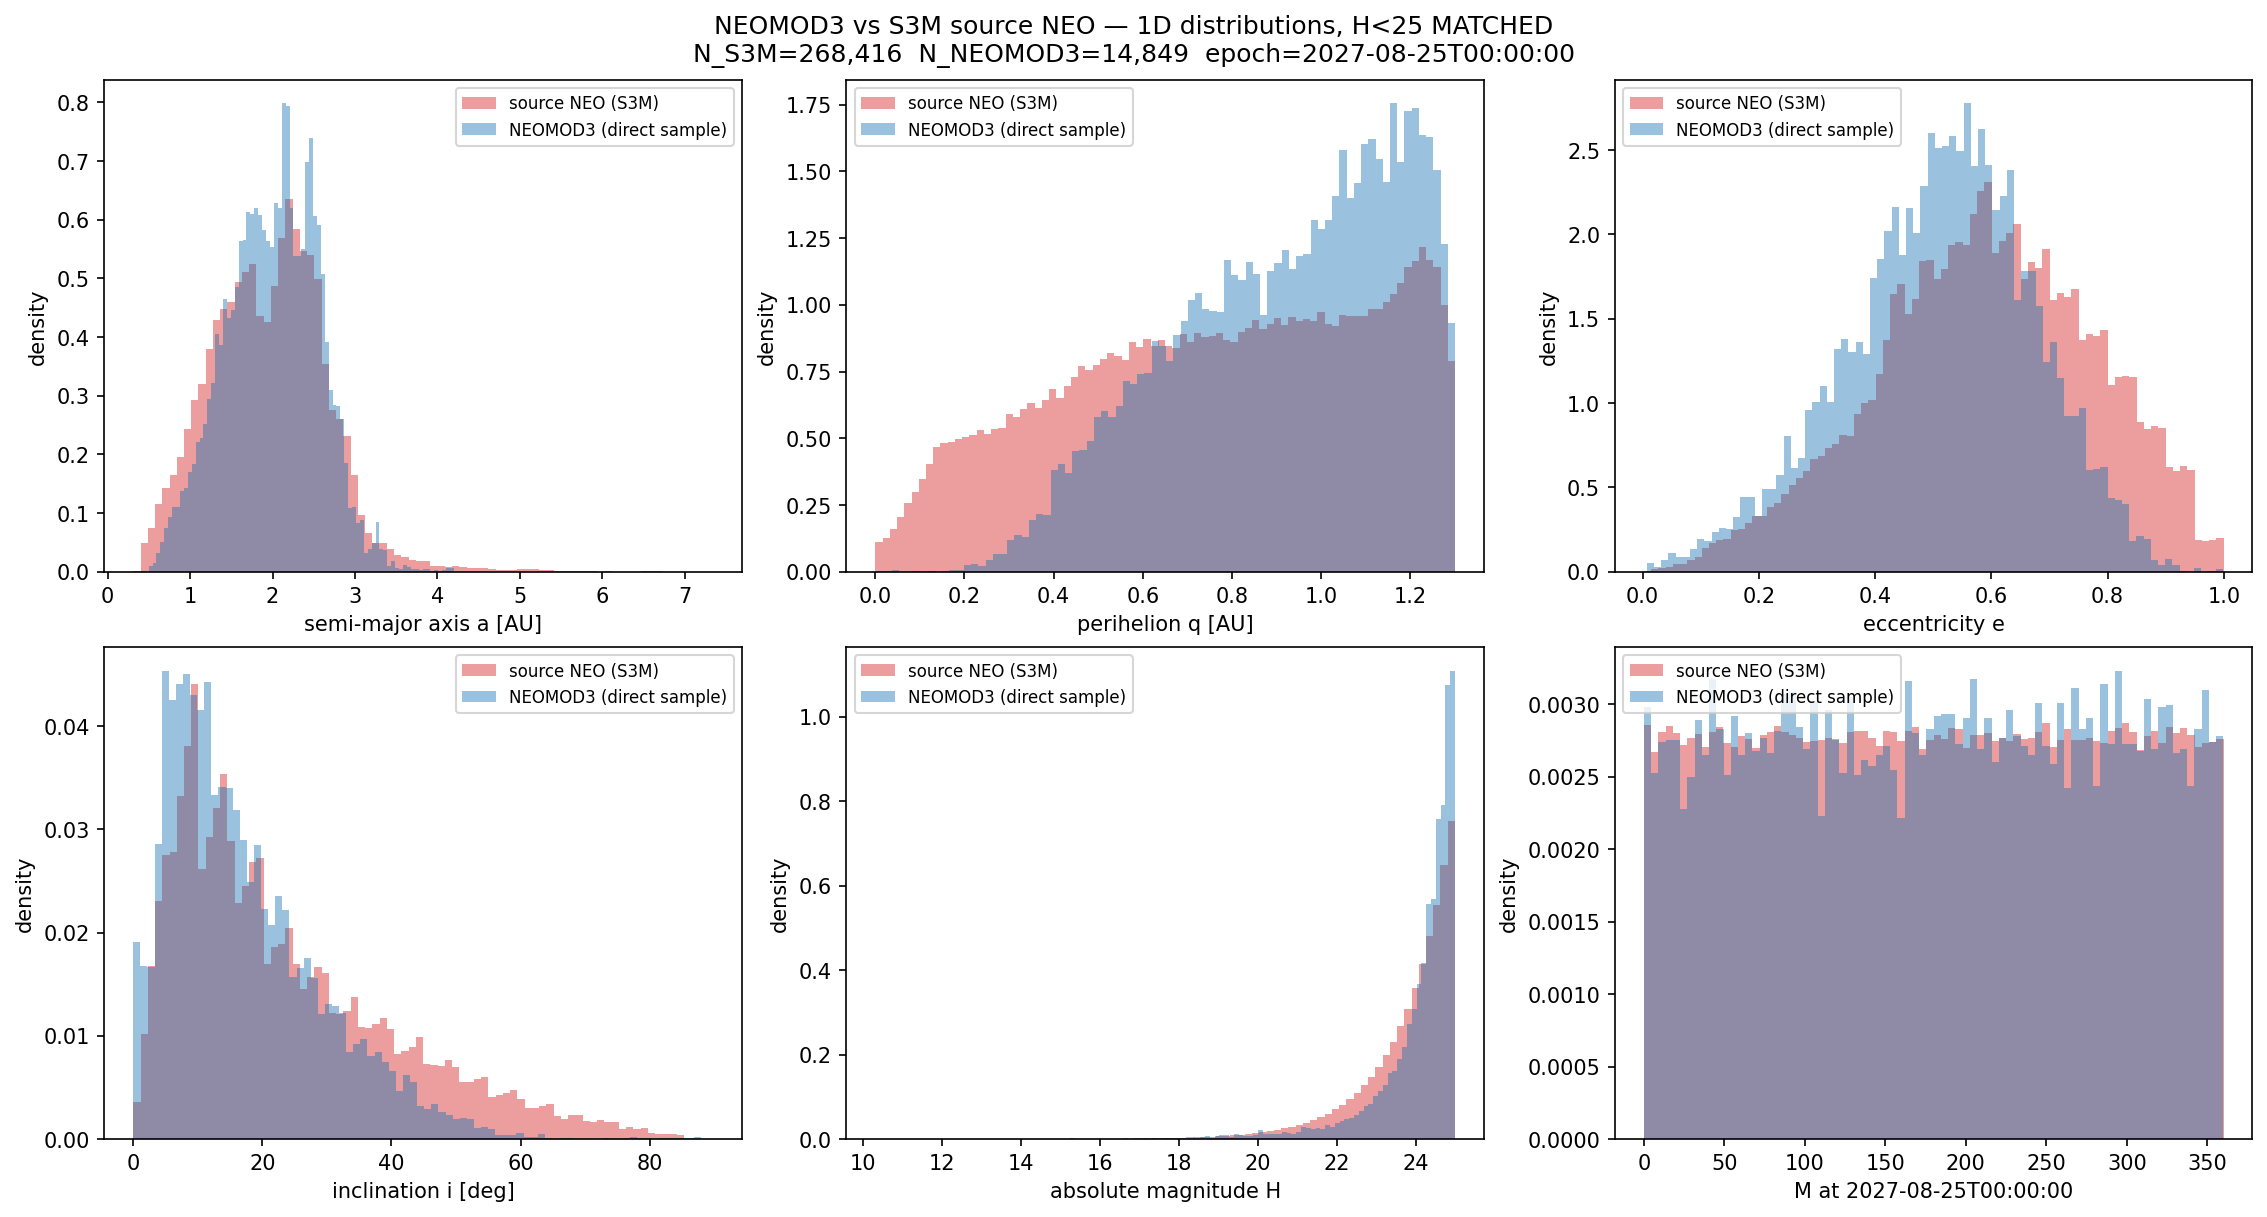

In [5]:
display(Image(filename=str(OUT/"s3m_vs_neomod3_1D_Hcut25.png")))

In [6]:

cut = stats[stats["sample"]=="H<25"]
comp = pd.DataFrame({
    "element":      [c for c in ["a","q","e","i"]],
    "KS full":      [float(full[full.column==c].ks_stat.iloc[0])  for c in ["a","q","e","i"]],
    "KS H<25":      [float(cut[cut.column==c].ks_stat.iloc[0])    for c in ["a","q","e","i"]],
})
comp["change"] = comp["KS H<25"] - comp["KS full"]
display(comp.round(4))
print("S3M  H<25:  268,416 of 268,511  (100.0%)  -- S3M is entirely below H=25")
print("NEOMOD3 H<25: 14,849 of 485,084 (  3.1%)  -- NEOMOD3 is dominated by faint objects")


S3M  H<25:  268,416 of 268,511  (100.0%)  -- S3M is entirely below H=25
NEOMOD3 H<25: 14,849 of 485,084 (  3.1%)  -- NEOMOD3 is dominated by faint objects


,element,KS full,KS H<25,change
0,a,0.0734,0.0743,0.0009
1,q,0.2130,0.2046,-0.0084
2,e,0.2227,0.1924,-0.0302
3,i,0.1766,0.1531,-0.0235


**Result: the differences survive.** Restricting to a matched H<25 regime barely moves the KS
statistics (q 0.213→0.205, e 0.223→0.192, i 0.177→0.153). So S3M and NEOMOD3 genuinely **disagree about
the NEO orbital distribution itself** — this is not an artifact of comparing different magnitude ranges.

Concretely, at matched H, NEOMOD3 has:
- **fewer very-low-perihelion objects** (q < 0.4) than S3M,
- a **lower eccentricity peak** (~0.52 vs ~0.59) and a thinner high-e tail,
- **fewer high-inclination objects** (S3M extends to i ~ 60–80° far more heavily).

Switching the clone source therefore *changes the intrinsic NEO population shape* the maps are built
from. That is the intended consequence of trusting a debiased model over a synthetic catalog — but it
should be stated explicitly rather than discovered later.


## 3 · Two-dimensional structure — and a visible S3M artifact

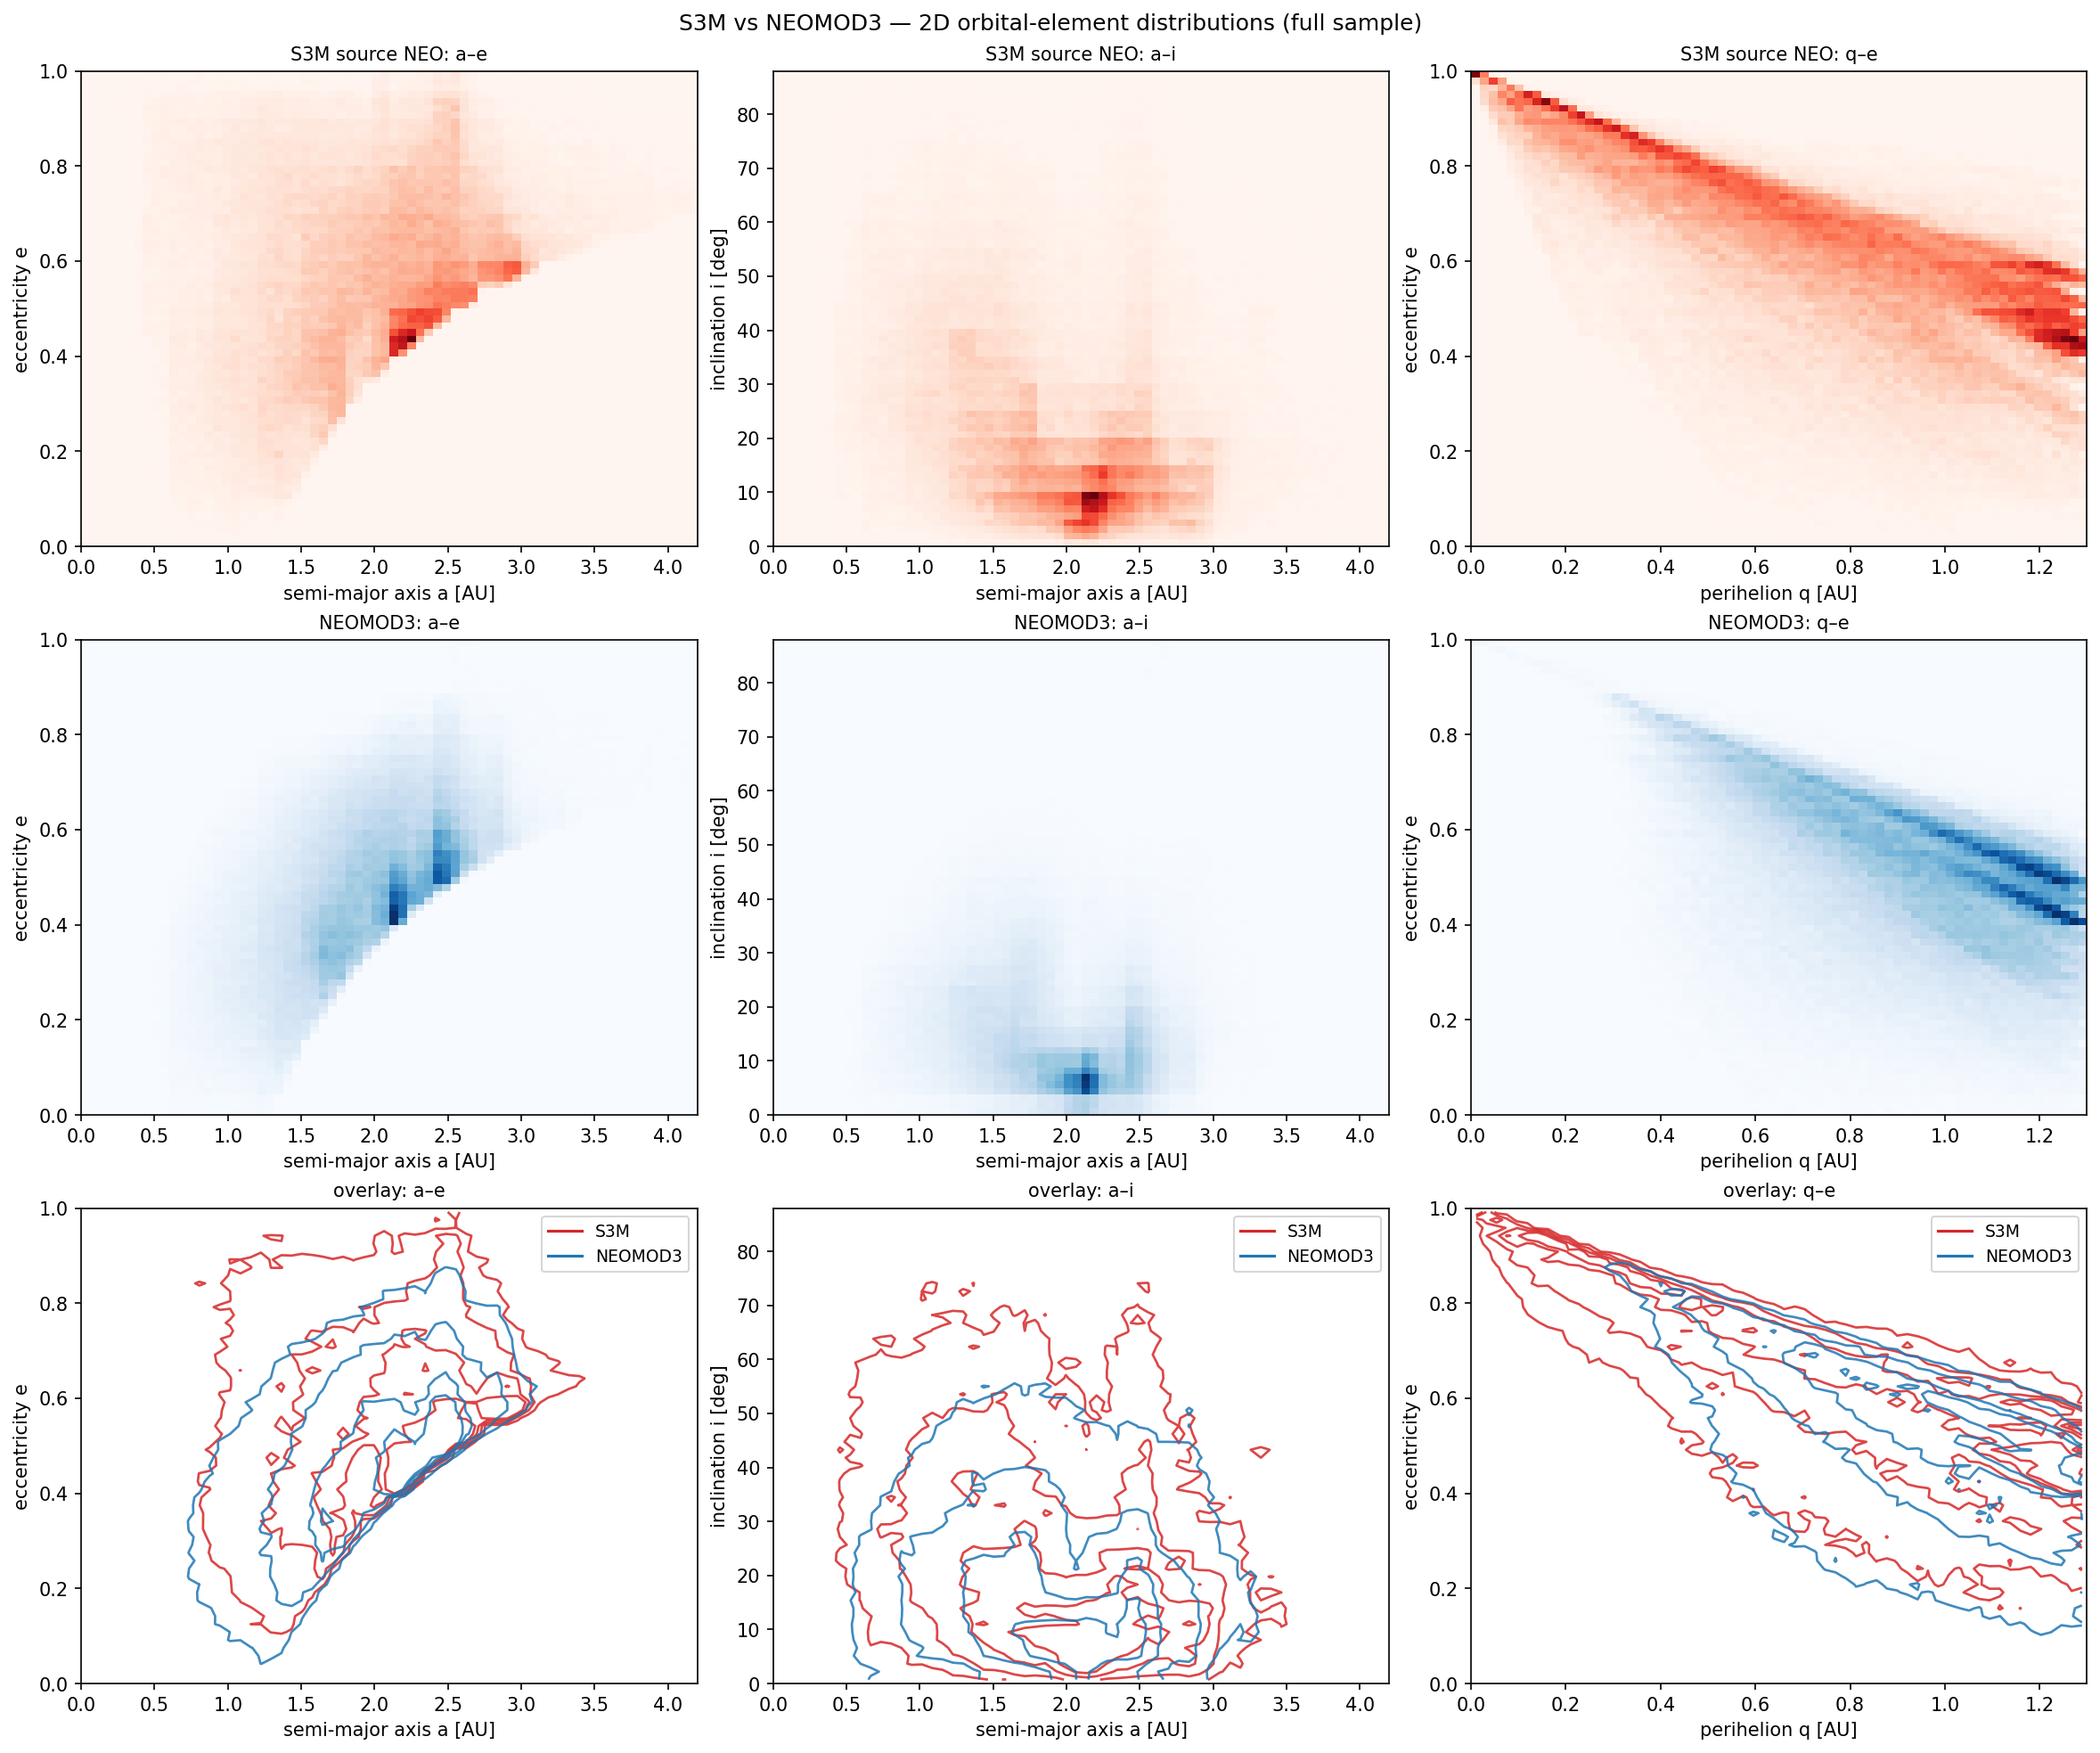

In [7]:
display(Image(filename=str(OUT/"s3m_vs_neomod3_2D_full.png")))

**Note the top-middle panel (S3M `a`–`i`):** S3M shows strong **horizontal striping** — discrete
inclination bands — and blocky structure in `a`–`e`. These are **generation artifacts of the synthetic
catalog**, not physics. NEOMOD3 (middle row) is smooth.

The overlay row (bottom) is the cleanest summary: the blue (NEOMOD3) contours sit **inside** the red
(S3M) ones almost everywhere — NEOMOD3 is a **more concentrated** distribution, S3M has broader tails
in both `e` and `i`.


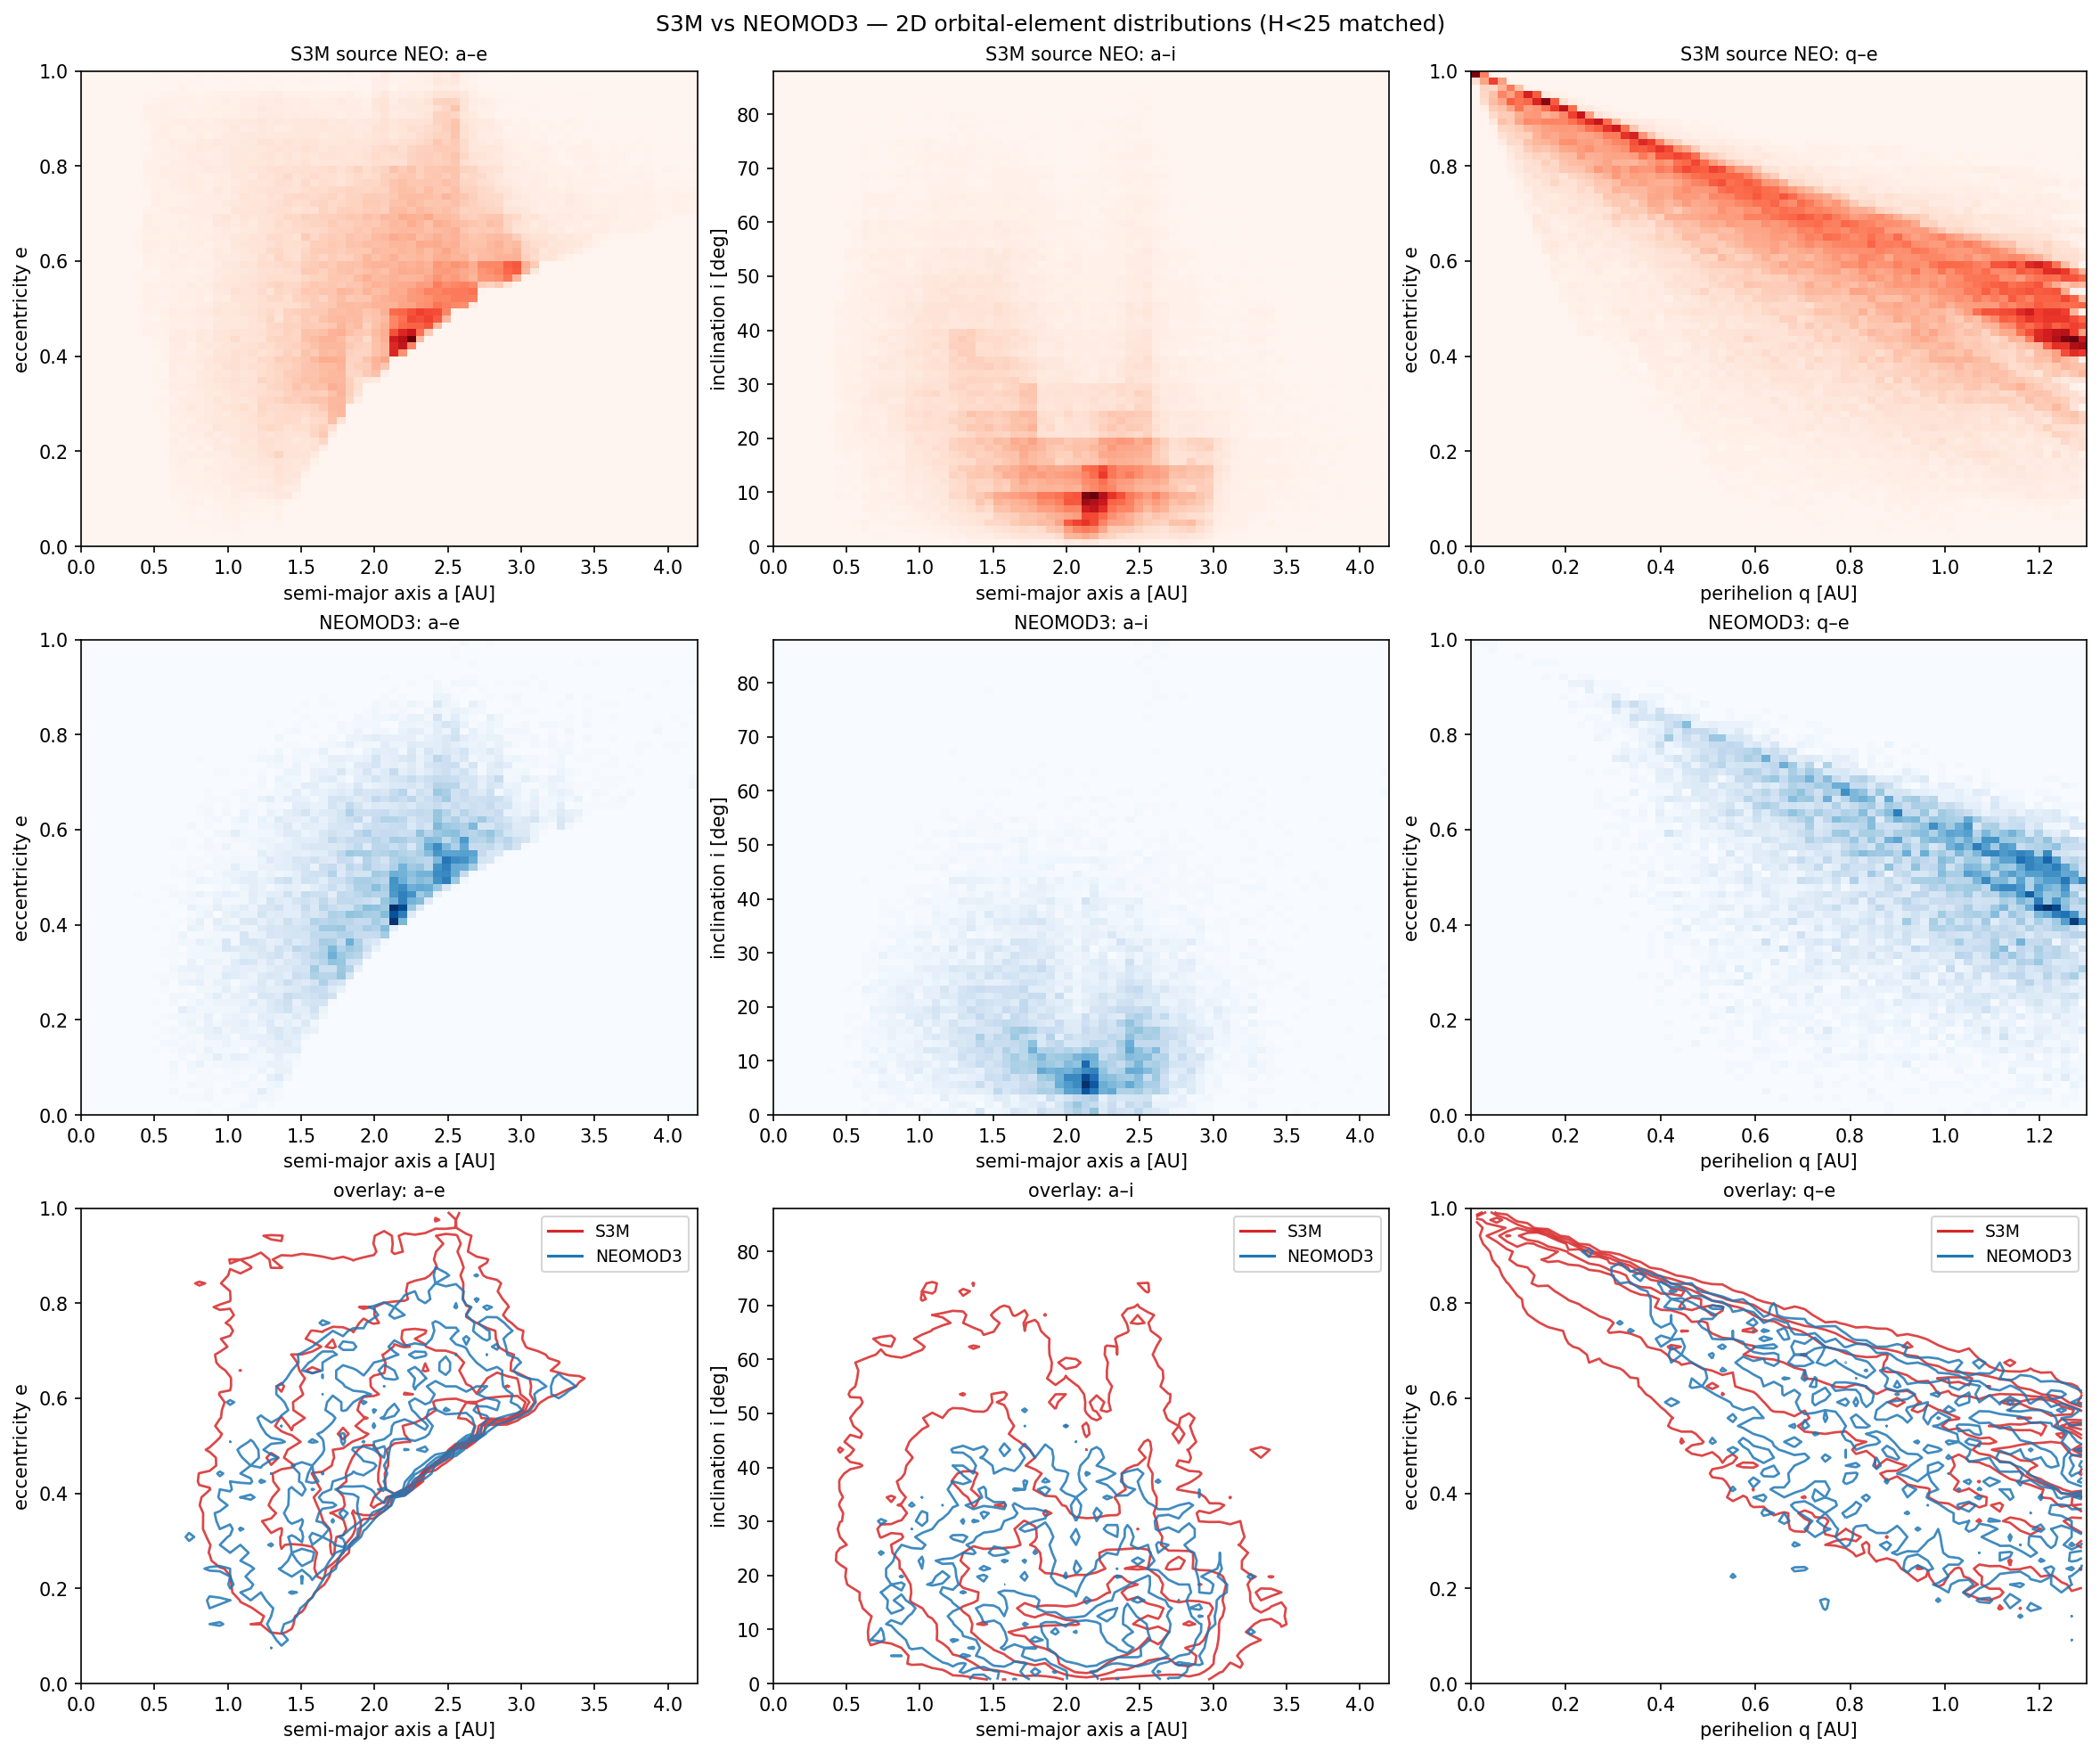

In [8]:
display(Image(filename=str(OUT/"s3m_vs_neomod3_2D_Hcut25.png")))

## 4 · What NEOMOD3 adds that S3M cannot provide at all

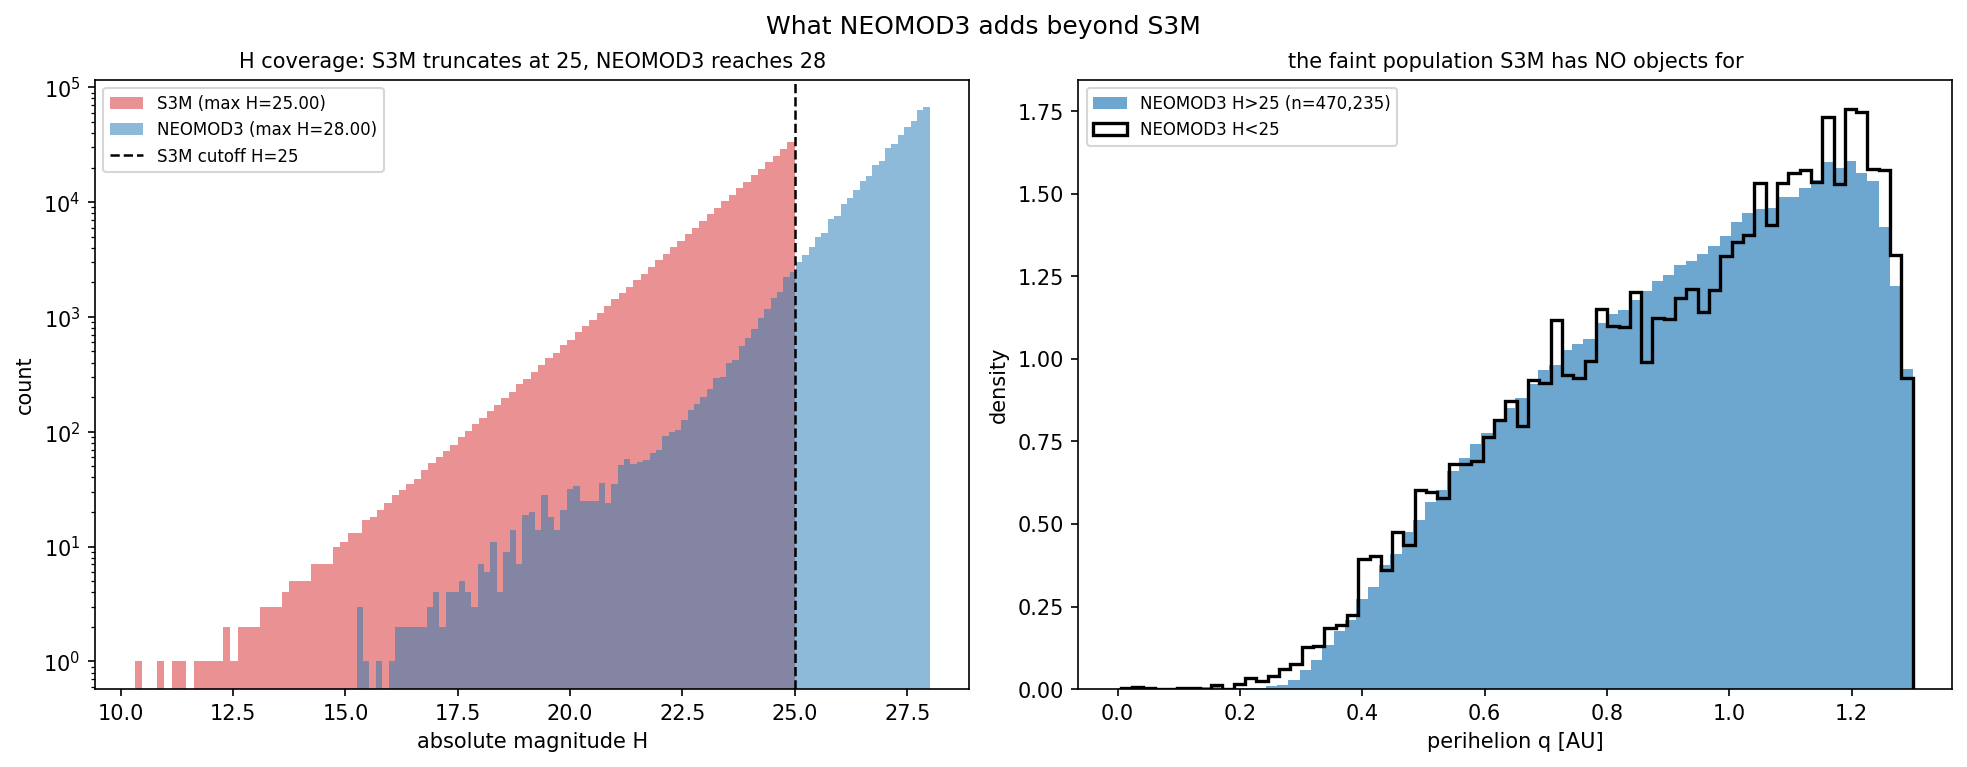

In [9]:
display(Image(filename=str(OUT/"neomod3_adds_faint_tail.png")))

In [10]:

s3m = pd.read_parquet(OUT/"s3m_source_neo.parquet")
nm3 = pd.read_parquet(OUT/"neomod3_samples.parquet")
print(f"S3M     H range: [{s3m.H.min():.2f}, {s3m.H.max():.2f}]   n={len(s3m):,}")
print(f"NEOMOD3 H range: [{nm3.H.min():.2f}, {nm3.H.max():.2f}]   n={len(nm3):,}")
faint = (nm3.H >= 25).sum()
print(f"\nNEOMOD3 samples with H >= 25 : {faint:,}  ({100*faint/len(nm3):.1f}%)")
print("S3M objects with H >= 25     : 0   <-- the catalog simply stops there")


S3M     H range: [10.31, 25.00]   n=268,511
NEOMOD3 H range: [15.25, 28.00]   n=485,084

NEOMOD3 samples with H >= 25 : 470,235  (96.9%)
S3M objects with H >= 25     : 0   <-- the catalog simply stops there


**This is the strongest argument for the switch.** ~97% of what NEOMOD3 describes is a population
S3M contains *zero* objects for. Any cloner anchored on S3M — GMM-smoothed or not — is structurally
incapable of representing the faint NEO population, which is precisely where detection is hardest and
where our VDP-zero / digest2-positive cohort lives.


## 5 · Does the GMM cloner reproduce NEOMOD3? — **No.**

The previous sections argue NEOMOD3 is the better *source*. But the production pipeline does not use
its source directly — it fits a **GaussianMixture** to it and samples clones from that. So the question
that actually matters is: **if we switch to NEOMOD3 but keep the GMM, do the maps see NEOMOD3?**

Test: feed NEOMOD3 orbits into the production cloner `_clone_neo_gmm` (the exact function the pipeline
calls for NEO, 80 components, `random_state=42`) and compare input against output.

This isolates the **GMM smoothing itself**: `_clone_neo_gmm` already augments its training set with
NEOMOD3 (`n_neomod3 = max(500, 10*len(train))`), so feeding it NEOMOD3 makes the training set
essentially pure NEOMOD3 (8,000 input → 85,572 training orbits). Any input/output difference is the
mixture model's doing, not a source mismatch.

Red = NEOMOD3 source (what we want the maps to see) · Blue = GMM clones (what they would actually get).

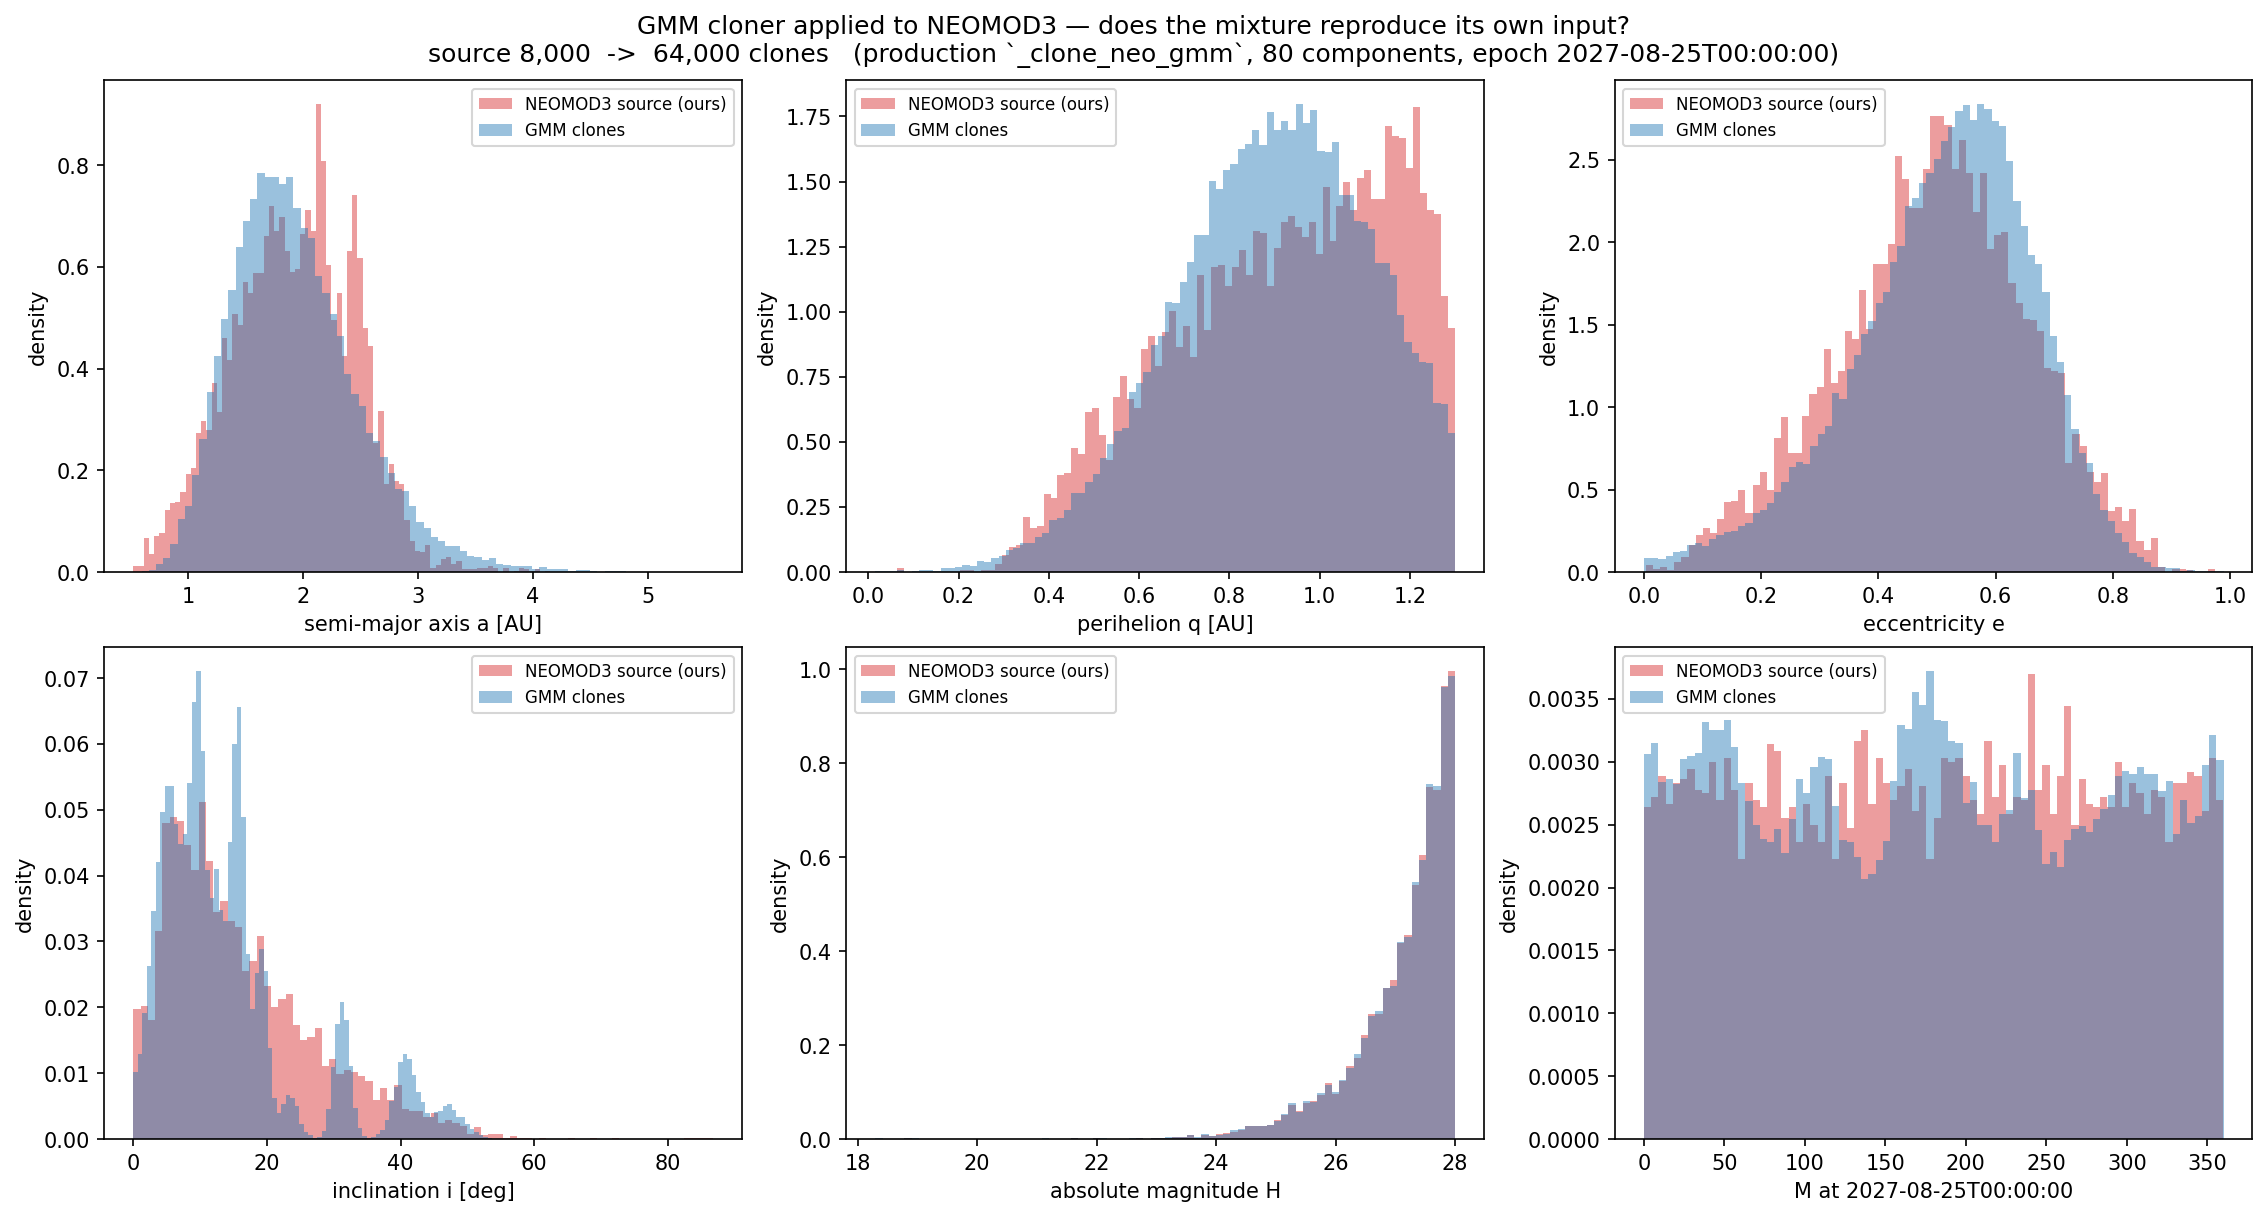

In [11]:
display(Image(filename=str(OUT/"gmm_clones_vs_neomod3_1D.png")))

In [12]:

g = pd.read_csv(OUT/"gmm_test_neomod3_stats.csv")
display(g[["column","label","source_median","clone_median","source_std","clone_std","ks_stat"]].round(4))
# how big is the GMM's distortion compared with the model difference we are switching source to fix?
cutks = {c: float(stats[(stats["sample"]=="H<25") & (stats.column==c)].ks_stat.iloc[0]) for c in ["a","q","e","i"]}
gmmks = {c: float(g[g.column==c].ks_stat.iloc[0]) for c in ["a","q","e","i"]}
cmp = pd.DataFrame({
    "element": ["a","q","e","i"],
    "S3M vs NEOMOD3 (H<25)": [cutks[c] for c in ["a","q","e","i"]],
    "GMM distortion of NEOMOD3": [gmmks[c] for c in ["a","q","e","i"]],
})
cmp["GMM distortion as % of the difference we are fixing"] = (
    100*cmp["GMM distortion of NEOMOD3"]/cmp["S3M vs NEOMOD3 (H<25)"]).round(0)
display(cmp.round(4))
print("GMM sample acceptance: 0.556  -> 44% of GMM draws are rejected as unphysical orbits")


GMM sample acceptance: 0.556  -> 44% of GMM draws are rejected as unphysical orbits


,column,label,source_median,clone_median,source_std,clone_std,ks_stat
0,a,semi-major axis a [AU],1.9388,1.8644,0.5262,0.5579,0.0625
1,q,perihelion q [AU],0.9497,0.9058,0.2431,0.2149,0.1105
2,e,eccentricity e,0.5010,0.5284,0.1613,0.1519,0.0769
3,i,inclination i [deg],13.4304,11.6407,11.2964,11.0669,0.1306
4,H,absolute magnitude H,27.3755,27.3738,0.8834,0.8913,0.0026
5,M_obs_deg,M at 2027-08-25T00:00:00,182.4857,177.3563,103.7694,105.0227,0.0233


,element,S3M vs NEOMOD3 (H<25),GMM distortion of NEOMOD3,GMM distortion as % of the difference we are fixing
0,a,0.0743,0.0625,84.0
1,q,0.2046,0.1105,54.0
2,e,0.1924,0.0769,40.0
3,i,0.1531,0.1306,85.0


**Result: the GMM measurably distorts the distribution it is supposed to reproduce.**

- **`q` (KS 0.110):** the sharp NEOMOD3 rise toward q ≈ 1.2–1.3 is **washed into a broad hump** peaking
  near 0.9–1.0; median moves 0.950 → 0.906. This is precisely the failure recorded in
  `cloning_gmm_neo.md` ("the GMM still smooths some details in q, especially the source spike").
- **`i` (KS 0.131, the worst):** median 13.43° → 11.64°, with spurious oscillations and a
  systematically under-represented 20–35° range.
- **`a` (KS 0.063):** median 1.939 → 1.864, plus a spurious tail beyond a ≈ 3.5 AU that the source
  barely has.
- **`e` (KS 0.077):** peak shifted, median 0.501 → 0.528.

**The `H` panel is the control that proves this.** `H` is the one quantity the GMM does *not* model —
it is sampled empirically from the source — and it comes back at **KS 0.0026**, essentially perfect.
So the a/q/e/i discrepancies are not sampling noise or a test artifact: they are what the mixture
model does to the orbital distribution.

**Why this decides the design.** Compare the GMM's distortion against the very model difference we are
switching source to capture (the H<25-matched S3M-vs-NEOMOD3 KS values):

| element | S3M vs NEOMOD3 | GMM distortion | ratio |
|---|---:|---:|---:|
| q | 0.205 | 0.110 | ~54% |
| e | 0.192 | 0.077 | ~40% |
| i | 0.153 | 0.131 | ~85% |

**Switching to NEOMOD3 but keeping the GMM would discard roughly half of the benefit** — and for
inclination, nearly all of it. That is the quantitative case for sampling NEOMOD3 **directly**, which
is what the new module does.

(Also: acceptance = 0.556 — the GMM throws away 44% of its own draws as unphysical orbits.)


## 6 · Design consequences for `velocity_density_pipeline_neomod_clone_only.py`

Four things this comparison settles, and one it raises:

**Settled**

1. **NEO clones come from NEOMOD3, sampled directly.** No GMM fit, no re-smoothing — the datacube *is*
   the distribution we want, and the sampler mechanics are validated (`M` KS = 0.002).
2. **Use NEOMOD3's own `H`**, jointly with `(a, e, i)`. The current code deliberately substitutes S3M's
   empirical H; with no GMM in the path there is no longer a reason to, and the joint H–orbit
   correlation is part of what makes the model debiased.
3. **MBA / TNO / Trojan: no cloning.** Use the real visible objects directly, `clone_factor = 1`.
4. Expect the **NEO population shape to shift** (q/e/i above) — a deliberate model change to report,
   not a regression to debug.

**Raised — needs a decision before the module is useful at scale**

5. **97% of naive NEOMOD3 samples are H ≥ 25.** The NEOMOD3 size distribution rises steeply toward small
   objects, so an unrestricted sample is overwhelmingly faint — and faint clones land in faint apparent
   magnitude bins or fall outside the maps' 14–25 range entirely and are discarded. To populate the
   *bright* mag bins we would need to sample enormously more orbits than we use.
   The fix is to **restrict the sampled H range** (the reference `neomod3.par` exposes exactly this as a
   diameter range, `0.05–3.0 km`) or to importance-sample per magnitude bin. Worth deciding deliberately
   rather than discovering it as a slow map build.


## 7 · How the NEOMOD3 cache is stored on disk — the HEALPix partition

Everything above is about *which* NEOs to clone. This section is about a purely practical problem
that had to be solved before the 667-map grid could be built at all.

**The problem.** The projection cache is one 7.3 GiB parquet file holding 97,056,755 clones spread
over the whole sky. But a single map only looks at a 30° patch. So every one of the 667 map tasks
was reading the entire all-sky file and then throwing away ~93% of it. Across the grid that is
about **5 TB of I/O to use ~0.9 TB of data**, and on a preemptible partition a task that gets
killed has to pay that startup cost all over again.

**Why not just slice by center?** Because the 667 patches overlap heavily — a clone near the
antisun is inside dozens of patches. Storing one slice per center would duplicate most clones many
times over and blow up the disk use.

**The fix: partition by sky tile, not by center.** HEALPix cuts the sphere into equal-area tiles.
At `nside=8` that is **768 tiles**, and every clone belongs to exactly **one** tile — no
duplication, no loss. Each map task then asks "which tiles does my 30° patch touch?" and reads only
those (~103 of 768).

**The margin matters.** A patch does not line up with tile edges, so a clone just inside the patch
can live in a tile whose center is outside it. The read therefore asks for a disc of
`30° + max_pixrad` where `max_pixrad = 7.47°` is the largest distance from a tile center to its
corner, with `inclusive=True`. This deliberately reads a **superset** — a few extra clones are
harmless because the exact 30° cut is applied afterwards anyway, whereas reading too *few* would
silently thin the map. Under-reading is prevented structurally, not by tuning.

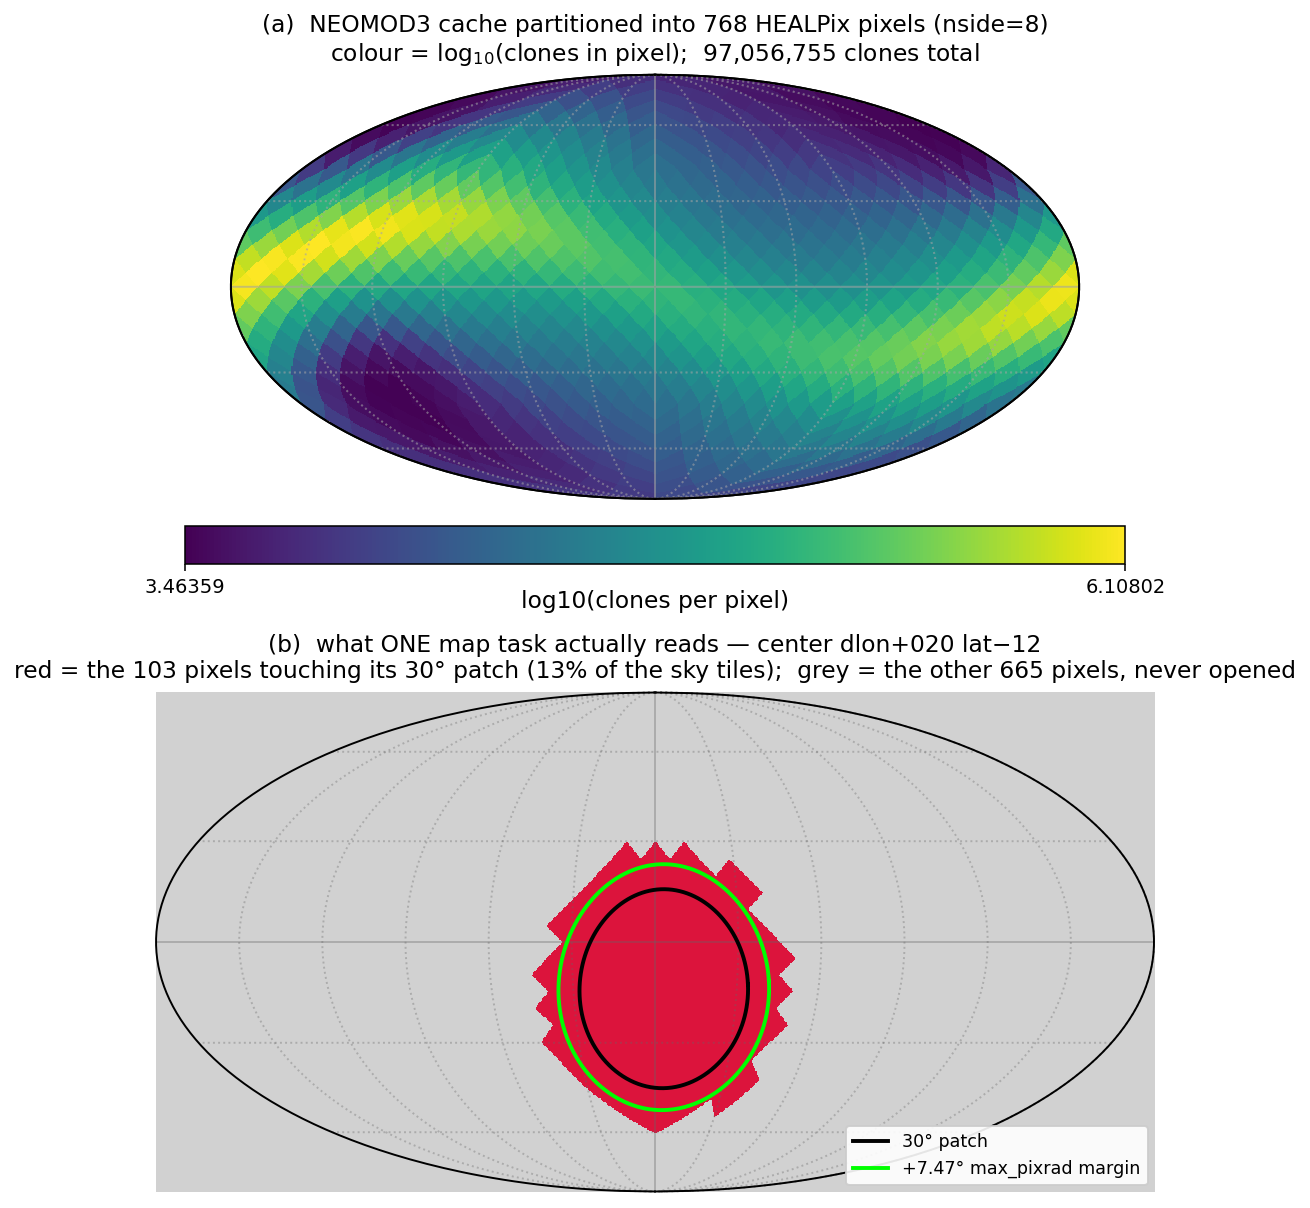

In [13]:
display(Image(filename=str(OUT/"healpix_partition_overview.png")))

**Reading the figure.**

*Panel (a)* — the 768 tiles coloured by how many clones each holds. The bright band is the
ecliptic: NEOs are strongly concentrated there, so the tiles are very uneven. The emptiest tile
holds 2,908 clones and the densest 1,282,395 — a factor of ~440. Equal *area* does not mean equal
*count*, which is why the per-task read size varies with where you point.

*Panel (b)* — what one map task actually opens. Red are the 103 tiles touching the patch for center
`dlon+020 lat−12`; the other 665 tiles are never read. The black circle is the true 30° patch and
the green circle is the `+7.47°` margin — note how the red tiles extend past the black circle. That
overshoot is the safety margin, and it is why the partitioned read gives *exactly* the same clone
set as reading the whole file.

In [14]:
summary = json.loads((OUT/"healpix_summary.json").read_text())
pd.DataFrame([
    ("tiles (nside=8)",          f"{summary['npix']}"),
    ("clones stored",            f"{summary['clones']:,}"),
    ("emptiest / densest tile",  f"{summary['emptiest_pixel']:,} / {summary['densest_pixel']:,} clones"),
    ("tiles read per map",       f"{summary['min_pixels']}-{summary['max_pixels']} (median {summary['median_pixels_per_center']})"),
    ("read per map: monolithic", f"{summary['monolithic_gib']:.2f} GiB"),
    ("read per map: HEALPix",    f"{summary['median_gib_per_center']:.2f} GiB"),
    ("I/O reduction",            f"{summary['speedup']:.1f}x"),
    ("cache size on disk",       f"{summary['monolithic_gib']:.2f} -> {summary['partitioned_gib']:.2f} GiB (+30%)"),
], columns=["quantity", "value"]).set_index("quantity")

,value
quantity,
tiles (nside=8),768
clones stored,"97,056,755"
emptiest / densest tile,"2,908 / 1,282,395 clones"
tiles read per map,98-108 (median 103)
read per map: monolithic,7.34 GiB
read per map: HEALPix,1.30 GiB
I/O reduction,5.7x
cache size on disk,7.34 -> 9.51 GiB (+30%)


**The one cost:** the partitioned cache is ~30% *larger* on disk (7.34 → 9.51 GiB). Splitting
into 768 files makes each row group smaller, and smaller row groups compress worse. That is a good
trade — disk is cheap, and repeated all-sky reads across 667 tasks were not.

So the honest number is a **5.7× reduction in I/O per task**, not the ~8–11× a naive
"103/768 of the sky" estimate would suggest. The naive figure ignores both the compression penalty
and the fact that the tiles a patch touches are the NEO-dense ecliptic ones, which are bigger than
average.

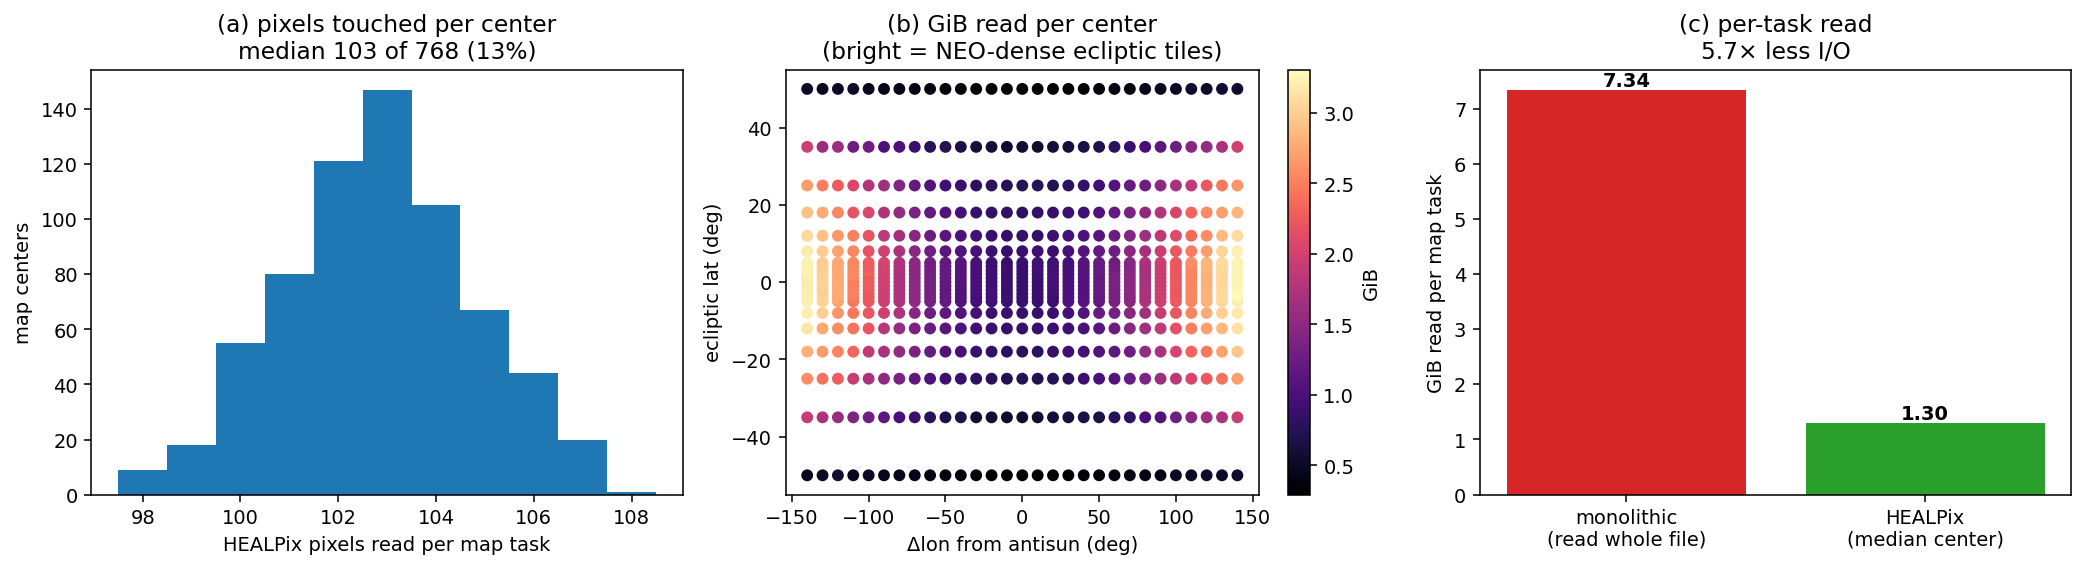

In [15]:
display(Image(filename=str(OUT/"healpix_cost.png")))

*Panel (a)* — every center reads between 98 and 108 tiles, tightly clustered around 103. The
spread is just how a fixed-radius disc lands on the tile grid at different latitudes.

*Panel (b)* — read size versus sky position, and this is the ecliptic showing up again. Centers near
`lat = 0` read the NEO-dense tiles (up to ~3.2 GiB); centers at `|lat| = 50` read nearly empty sky
(~0.3 GiB). Same number of tiles, ~10× different data volume.

*Panel (c)* — the bottom line: 7.34 GiB → 1.30 GiB for a typical map task.

### Does this risk changing the science?

No, and that was checked rather than assumed, because a partitioning bug would quietly *thin* the
NEO clone set and bias every map. Four tiers of validation, all passed:

| test | what it checks | result |
|---|---|---|
| **T1** | all 97,056,755 rows present, column checksums match, and re-deriving each row's tile from its own ra/dec agrees with where it was stored (1M sample) | 0 mismatches |
| **T2** | for 12 centers spanning antisun, both sun-exclusion edges and both poles: partitioned read → 30° cut vs whole-file read → 30° cut | element-wise **identical** |
| **T3** | rebuild whole maps both ways | **bit-identical** arrays |
| **T4** | re-score tracklets with maps built each way | identical AUC / F1 |

The partition is a pure storage change. It cannot alter the result, and T3 confirms it does not.

### One implementation detail worth remembering

The first build of this cache ran at ~2 MB/s and would have taken 45+ minutes. The cause: the cache
is in projection order, i.e. random sky positions, so each batch of rows scattered across all 768
open output files — thousands of tiny simultaneous appends, which GPFS handles badly. Sorting the
rows by tile before writing turns it into 768 sequential bulk writes. Same output, **6 seconds**.

## 8 · Reproduce

```bash
PY=/mmfs1/gscratch/dirac/ds2004/sorcha/conda_prep/bin/python
# base comparison (loads S3M, samples NEOMOD3, 1D plot + stats)
sbatch neomod/pipeline/slurm/compare_s3m_vs_neomod3.sbatch
# extended (H<25 matched cut, 2D panels, faint-tail figure) — reads the saved parquets
$PY neomod/pipeline/compare_s3m_vs_neomod3_extended.py
```

**Two traps worth knowing** (both hit during this work):

- `load_s3m_population()` defaults to the **hybrid** catalog (`t_0` = 2023). The sbatch sets
  `VDP_LOADER=s3m` to get pure S3M elements (`t_0` = 2008). See `fixing_integrator.md` §13.6 — the
  hybrid elements propagate up to 77° away from the validated pure-S3M cache.
- `s3m_loader` searches `['.', 'S3Mdata']` **relative to CWD**, so the script must `chdir` into
  `neomod/` regardless of the Slurm `--chdir`.

# HEALPix partition + its validation, and the figures in section 7
$PY neomod/pipeline/neomod3_cache_healpix.py build
$PY neomod/pipeline/neomod3_cache_healpix.py validate     # T1
$PY neomod/pipeline/neomod3_cache_healpix.py validate2    # T2
$PY neomod/pipeline/make_healpix_figures.py
```

```
